## Package and setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from darts import TimeSeries
from darts.models import LinearRegressionModel
from darts.models import RandomForestModel
from darts.dataprocessing.transformers import Scaler
from darts.metrics import mape, rmse, mae, r2_score
import shap

COLORS = {
    'IHSG': '#2E7D32',
    'IHSG_light': '#4CAF50',
    'IHSG_dark': '#1B5E20',    
    'Inflation': '#D32F2F',
    'BI_Rate': '#F57C00',        
    'M2_YoY': '#1976D2',         
    'USDIDR': '#7B1FA2',         
    'NPL_Ratio': '#C2185B',      
    'train': '#2E7D32',
    'actual': '#1976D2',
    'predicted': '#D32F2F',
    'error': '#9E9E9E',
    'split_line': '#616161',
}

COLOR_PALETTE = ['#2E7D32', '#D32F2F', '#F57C00', '#1976D2', '#7B1FA2', '#C2185B']

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100          # Display DPI
plt.rcParams['savefig.dpi'] = 300         # Export DPI (publication quality)
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0.1

# font
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Georgia']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

# line 
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['axes.linewidth'] = 0.8

# grid
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linewidth'] = 0.5

# legend
plt.rcParams['legend.framealpha'] = 0.9
plt.rcParams['legend.edgecolor'] = '0.8'

The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md


## Data gathering and preprocessing

In [2]:
url = 'https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/model1-new.csv'
df = pd.read_csv(url)

# display basic info
print("="*60)
print("DATA OVERVIEW")
print("="*60)
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumns: {df.columns.tolist()}")
print("\n" + "="*60)
print("FIRST 10 ROWS")
print("="*60)
df.head(10)

DATA OVERVIEW
Shape: 122 rows × 8 columns

Columns: ['Date', 'IHSG', 'Inflation Rate YoY', 'Money Supply M2 YoY', 'USDIDR', 'BI Interest Rate', 'npl_ratio', 'Money Supply M2 MoM']

FIRST 10 ROWS


,Date,IHSG,Inflation Rate YoY,Money Supply M2 YoY,USDIDR,BI Interest Rate,npl_ratio,Money Supply M2 MoM
0,31/01/2025,7109.196,0.76,5.46,16300.0,5.75%,2.18%,-0.52
1,31/12/2024,7079.905,1.57,4.76,16102.0,6.00%,2.08%,1.23
2,30/11/2024,7114.266,1.55,6.53,15845.0,6.00%,2.19%,0.57
3,31/10/2024,7574.019,1.71,6.77,15697.0,6.00%,2.20%,0.38
4,30/09/2024,7527.929,1.84,7.19,15140.0,6.00%,2.21%,0.81
5,31/08/2024,7670.733,2.12,7.30,15455.0,6.25%,2.26%,-0.09
6,31/07/2024,7255.762,2.13,7.59,16260.0,6.25%,2.27%,-0.35
7,30/06/2024,7063.577,2.51,7.67,16375.0,6.25%,2.26%,0.52
8,31/05/2024,6970.736,2.84,7.59,16250.0,6.25%,2.34%,0.47
9,30/04/2024,7234.197,3.00,6.87,16260.0,6.25%,2.33%,0.39


In [3]:
# Check data types and missing values
print("="*60)
print("DATA TYPES & MISSING VALUES")
print("="*60)
df.info()
print("\n" + "="*60)
print("MISSING VALUES PER COLUMN")
print("="*60)
print(df.isnull().sum())

DATA TYPES & MISSING VALUES
<class 'pandas.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 122 non-null    str    
 1   IHSG                 122 non-null    float64
 2   Inflation Rate YoY   121 non-null    float64
 3   Money Supply M2 YoY  121 non-null    float64
 4   USDIDR               121 non-null    float64
 5   BI Interest Rate     121 non-null    str    
 6   npl_ratio            121 non-null    str    
 7   Money Supply M2 MoM  121 non-null    float64
dtypes: float64(5), str(3)
memory usage: 7.8 KB

MISSING VALUES PER COLUMN
Date                   0
IHSG                   0
Inflation Rate YoY     1
Money Supply M2 YoY    1
USDIDR                 1
BI Interest Rate       1
npl_ratio              1
Money Supply M2 MoM    1
dtype: int64


In [4]:
df_clean = df.copy()

df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='%d/%m/%Y')

pct_columns = ['BI Interest Rate', 'npl_ratio']
for col in pct_columns:
        df_clean[col] = df_clean[col].str.replace('%', '').astype(float)

df_clean = df_clean.sort_values('Date').reset_index(drop=True)

df_clean.columns = ['Date', 'IHSG', 'Inflation_YoY', 'M2_YoY', 'USDIDR', 'BI_Rate', 'NPL_Ratio', 'M2_MoM']

print("="*60)
print("CLEANED DATA")
print("="*60)
print(f"Date Range: {df_clean['Date'].min()} to {df_clean['Date'].max()}")
print(f"Total Months: {len(df_clean)}")
print("\nData Types after cleaning:")
print(df_clean.dtypes)
print("\n")
df_clean.head(10)

CLEANED DATA
Date Range: 2014-12-30 00:00:00 to 2025-01-31 00:00:00
Total Months: 122

Data Types after cleaning:
Date             datetime64[us]
IHSG                    float64
Inflation_YoY           float64
M2_YoY                  float64
USDIDR                  float64
BI_Rate                 float64
NPL_Ratio               float64
M2_MoM                  float64
dtype: object




,Date,IHSG,Inflation_YoY,M2_YoY,USDIDR,BI_Rate,NPL_Ratio,M2_MoM
0,2014-12-30,5226.950,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-31,5289.404,6.96,14.31,12755.0,7.75,2.37,0.04
2,2015-02-28,5450.294,6.29,16.04,12928.0,7.50,2.43,1.04
3,2015-03-31,5518.675,6.38,16.26,13075.0,7.50,2.40,0.67
4,2015-04-30,5086.425,6.79,14.88,12964.0,7.50,2.48,0.69
5,2015-05-31,5216.379,7.15,13.42,13225.0,7.50,2.58,0.30
6,2015-06-30,4910.658,7.26,12.98,13333.0,7.50,2.56,1.64
7,2015-07-31,4802.529,7.26,12.50,13531.0,7.50,2.70,0.33
8,2015-08-31,4509.607,7.18,13.32,14053.0,7.50,2.76,0.71
9,2015-09-30,4223.908,6.83,12.43,14651.0,7.50,2.71,2.37


In [5]:
# Descriptive statistics
print("="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)
df_clean.describe().round(2)

DESCRIPTIVE STATISTICS


,Date,IHSG,Inflation_YoY,M2_YoY,USDIDR,BI_Rate,NPL_Ratio,M2_MoM
count,122,122.00,121.00,121.00,121.00,121.00,121.00,121.00
mean,2020-01-14 21:38:21.639344,6070.41,3.36,8.81,14363.80,5.25,2.77,0.66
min,2014-12-30 00:00:00,4223.91,0.76,3.35,12755.00,3.50,2.08,-3.18
25%,2017-07-07 18:00:00,5386.23,2.48,6.77,13655.00,4.25,2.52,0.18
50%,2020-01-15 12:00:00,6037.29,3.18,8.18,14273.00,5.25,2.76,0.66
75%,2022-07-23 06:00:00,6842.26,3.83,10.53,14903.00,6.00,3.05,1.23
max,2025-01-31 00:00:00,7670.73,7.26,16.26,16375.00,7.75,3.35,5.28
std,NaN,850.58,1.49,2.74,895.79,1.24,0.32,1.30


In [6]:
df_clean = df_clean.dropna().reset_index(drop=True)

## 4. Exploratory Data Analysis (EDA)

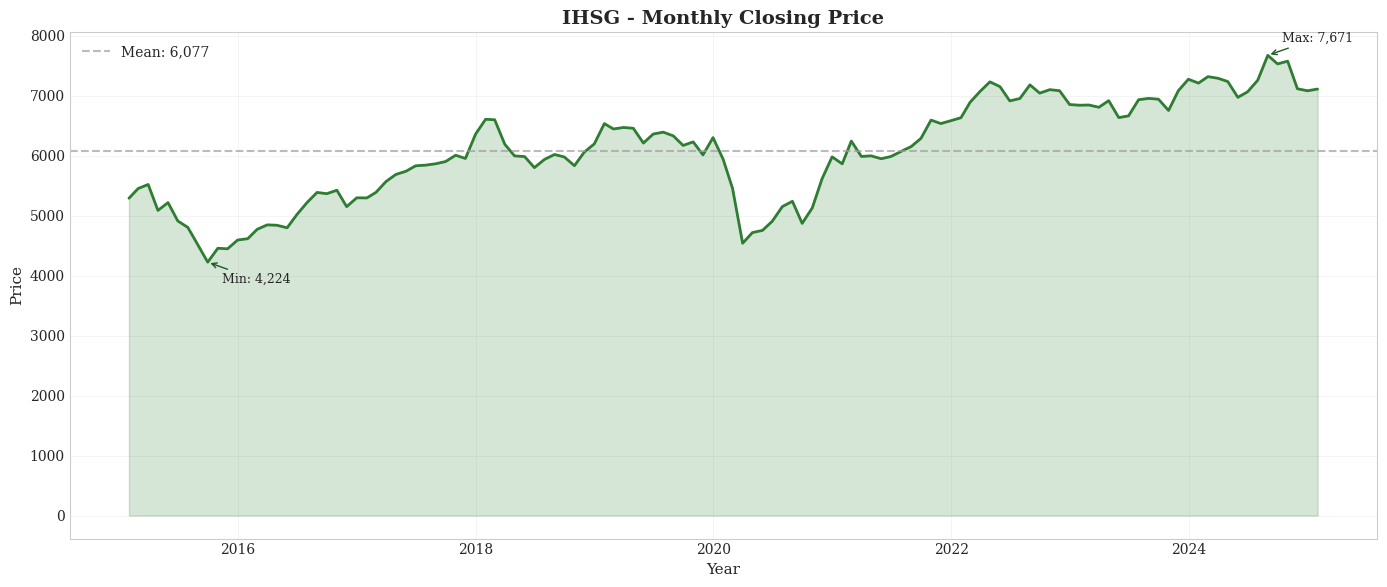

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_clean['Date'], df_clean['IHSG'], color=COLORS['IHSG'], linewidth=2)
ax.fill_between(df_clean['Date'], df_clean['IHSG'], alpha=0.2, color=COLORS['IHSG'])

# Add mean line
ihsg_mean = df_clean['IHSG'].mean()
ax.axhline(y=ihsg_mean, color=COLORS['error'], linestyle='--', alpha=0.7, 
           label=f'Mean: {ihsg_mean:,.0f}')

ax.set_title('IHSG - Monthly Closing Price', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Price')
ax.legend(loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.3)

# Add annotations for min/max
ihsg_max_idx = df_clean['IHSG'].idxmax()
ihsg_min_idx = df_clean['IHSG'].idxmin()
ax.annotate(f"Max: {df_clean.loc[ihsg_max_idx, 'IHSG']:,.0f}", 
            xy=(df_clean.loc[ihsg_max_idx, 'Date'], df_clean.loc[ihsg_max_idx, 'IHSG']),
            xytext=(10, 10), textcoords='offset points', fontsize=9,
            arrowprops=dict(arrowstyle='->', color=COLORS['IHSG_dark']))
ax.annotate(f"Min: {df_clean.loc[ihsg_min_idx, 'IHSG']:,.0f}", 
            xy=(df_clean.loc[ihsg_min_idx, 'Date'], df_clean.loc[ihsg_min_idx, 'IHSG']),
            xytext=(10, -15), textcoords='offset points', fontsize=9,
            arrowprops=dict(arrowstyle='->', color=COLORS['IHSG_dark']))

plt.tight_layout()
plt.savefig('model1-figure/eda_ihsg.png', dpi=300, bbox_inches='tight')
plt.show()

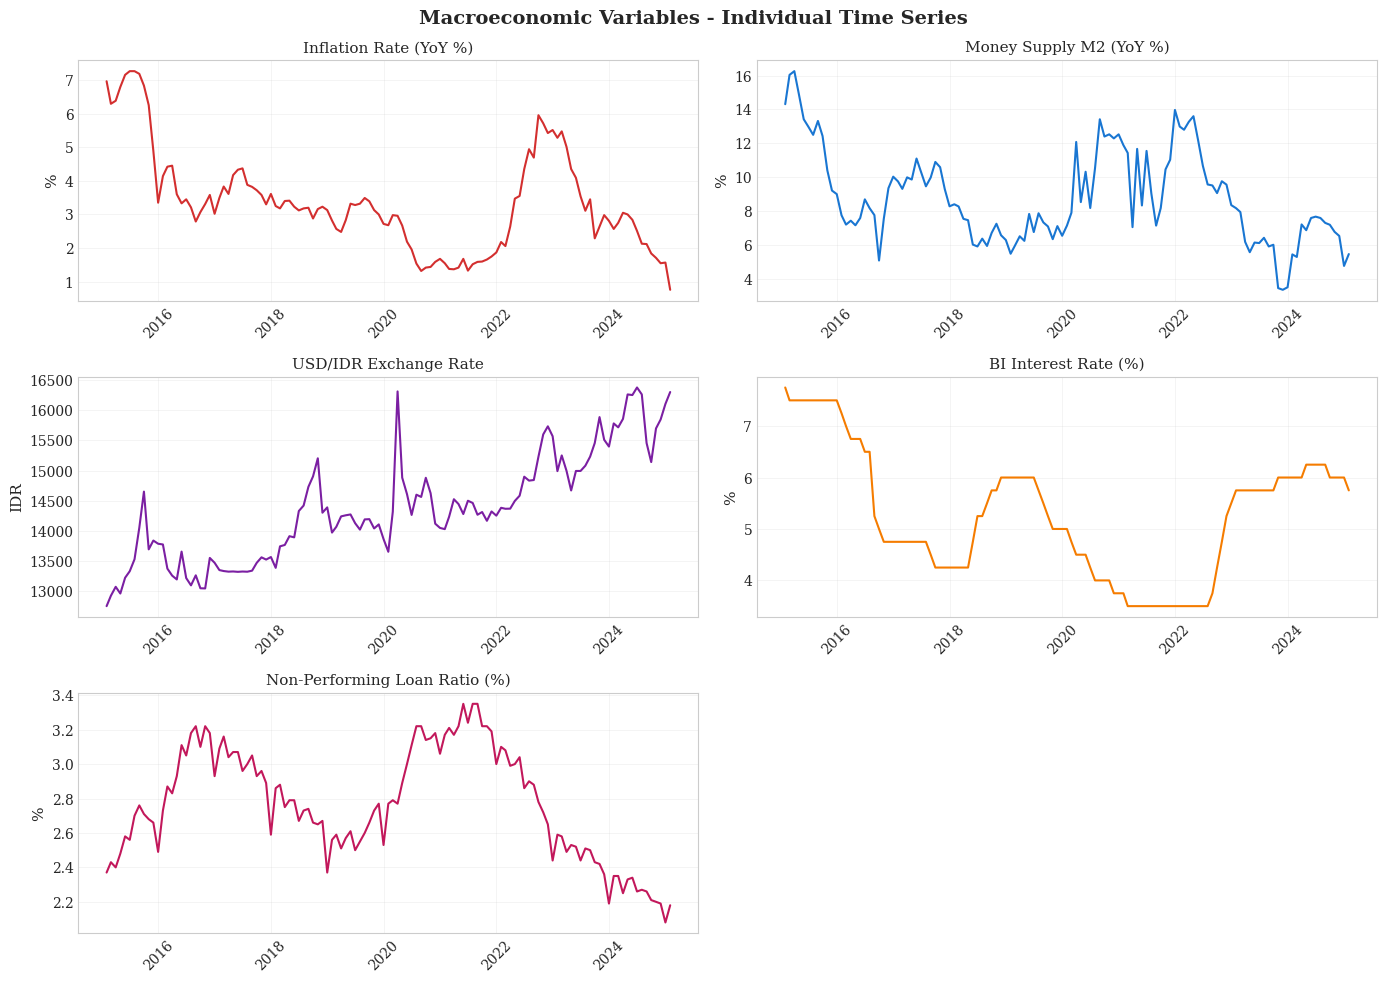

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Macroeconomic Variables - Individual Time Series', fontsize=14, fontweight='bold')

plot_config = [
    ('Inflation_YoY', COLORS['Inflation'], 'Inflation Rate (YoY %)', '%'),
    ('M2_YoY', COLORS['M2_YoY'], 'Money Supply M2 (YoY %)', '%'),
    ('USDIDR', COLORS['USDIDR'], 'USD/IDR Exchange Rate', 'IDR'),
    ('BI_Rate', COLORS['BI_Rate'], 'BI Interest Rate (%)', '%'),
    ('NPL_Ratio', COLORS['NPL_Ratio'], 'Non-Performing Loan Ratio (%)', '%'),
]

for idx, (col, color, title, ylabel) in enumerate(plot_config):
    ax = axes[idx // 2, idx % 2]
    ax.plot(df_clean['Date'], df_clean[col], color=color, linewidth=1.5)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

# Hide the last empty subplot
axes[2, 1].axis('off')

plt.tight_layout()
plt.savefig('model1-figure/eda_covariates_individual.png', dpi=300, bbox_inches='tight')
plt.show()

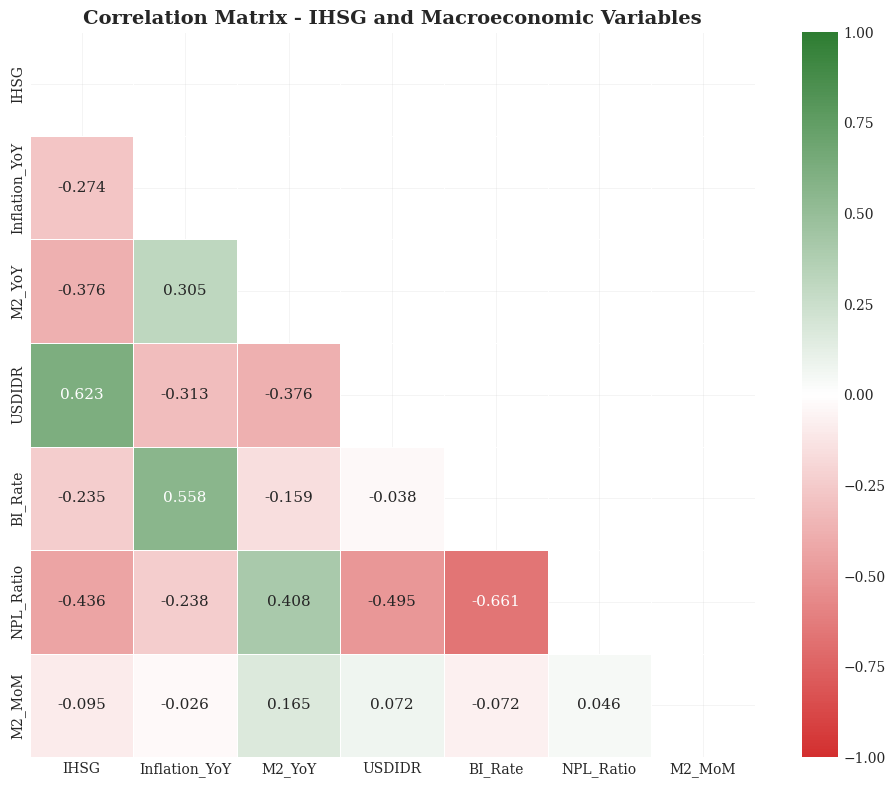

✅ Figure saved: model1-figure/correlation_matrix.png (300 DPI)

CORRELATION WITH IHSG
USDIDR          : +0.6227 (Moderate ↑ Positive)
M2_MoM          : -0.0951 (Weak ↓ Negative)
BI_Rate         : -0.2353 (Weak ↓ Negative)
Inflation_YoY   : -0.2740 (Weak ↓ Negative)
M2_YoY          : -0.3763 (Weak ↓ Negative)
NPL_Ratio       : -0.4360 (Moderate ↓ Negative)


In [10]:
fig, ax = plt.subplots(figsize=(10, 8))

corr_matrix = df_clean.drop('Date', axis=1).corr()

# Custom colormap: Green (positive with IHSG) to Red (negative)
from matplotlib.colors import LinearSegmentedColormap
colors_cmap = ['#D32F2F', '#FFFFFF', '#2E7D32']  # Red - White - Green
custom_cmap = LinearSegmentedColormap.from_list('thesis_cmap', colors_cmap, N=256)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap=custom_cmap, 
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 11}, vmin=-1, vmax=1)

ax.set_title('Correlation Matrix - IHSG and Macroeconomic Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model1-figure/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Figure saved: model1-figure/correlation_matrix.png (300 DPI)")
print("\n" + "="*60)
print("CORRELATION WITH IHSG")
print("="*60)
ihsg_corr = corr_matrix['IHSG'].drop('IHSG').sort_values(ascending=False)
for var, corr in ihsg_corr.items():
    direction = "↑ Positive" if corr > 0 else "↓ Negative"
    strength = "Strong" if abs(corr) > 0.7 else "Moderate" if abs(corr) > 0.4 else "Weak"
    print(f"{var:15} : {corr:+.4f} ({strength} {direction})")

## 5. Create Darts TimeSeries Objects

In [11]:
IHSG_series = TimeSeries.from_dataframe(df_clean, time_col='Date', value_cols='IHSG', freq='ME')
COVAR_series = TimeSeries.from_dataframe(df_clean, time_col='Date', value_cols=['M2_YoY', 'USDIDR', 'NPL_Ratio'], freq='ME')

In [12]:
train_ratio = 0.8
split_point = int(len(IHSG_series) * train_ratio)

ihsg_train = IHSG_series[:split_point]
ihsg_test = IHSG_series[split_point:]

covar_train = COVAR_series[:split_point]
covar_test = COVAR_series[split_point:]

<Axes: xlabel='Date'>

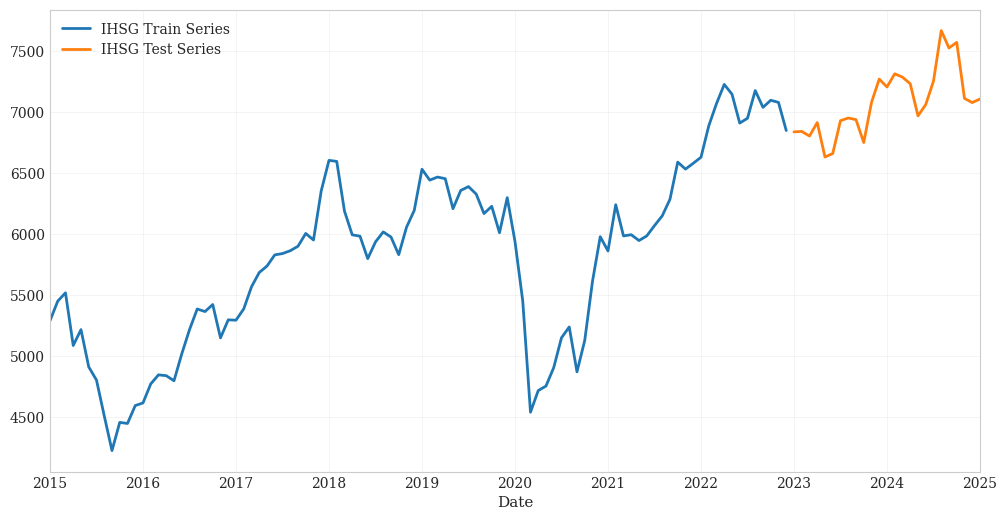

In [13]:
ihsg_train.plot(label='IHSG Train Series')
ihsg_test.plot(label='IHSG Test Series')

<Axes: xlabel='Date'>

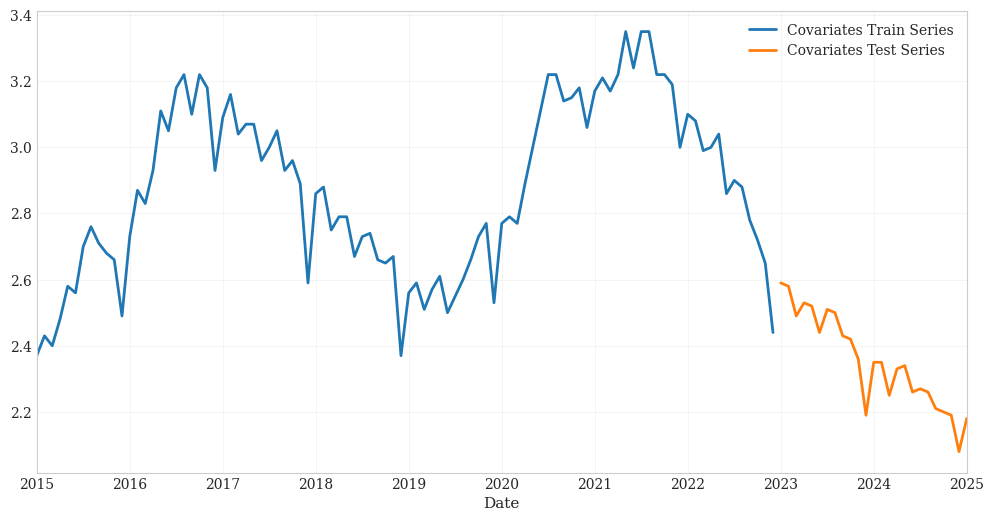

In [14]:
covar_train['NPL_Ratio'].plot(label='Covariates Train Series')
covar_test['NPL_Ratio'].plot(label='Covariates Test Series')

In [15]:
ihsg_train

,IHSG
Date,
2015-01-31,5289.404
2015-02-28,5450.294
2015-03-31,5518.675
2015-04-30,5086.425
2015-05-31,5216.379
...,...
2022-08-31,7178.590
2022-09-30,7040.798
2022-10-31,7098.890


In [16]:
print("DARTS TIMESERIES")
print("="*60)
print(f"Target Series (IHSG):")
print(f"  - Start: {IHSG_series.start_time()}")
print(f"  - End: {IHSG_series.end_time()}")
print(f"  - Length: {len(IHSG_series)} time steps")
print(f"  - Frequency: {IHSG_series.freq}")
print(f"\nCovariates:")
print(f"  - Components: {COVAR_series.components.tolist()}")
print(f"  - Length: {len(COVAR_series)} time steps")

DARTS TIMESERIES
Target Series (IHSG):
  - Start: 2015-01-31 00:00:00
  - End: 2025-01-31 00:00:00
  - Length: 121 time steps
  - Frequency: <MonthEnd>

Covariates:
  - Components: ['M2_YoY', 'USDIDR', 'NPL_Ratio']
  - Length: 121 time steps


## train, test, split and normalization

In [17]:
from darts.dataprocessing.transformers import Scaler
from sklearn.preprocessing import MinMaxScaler

scaler_IHSG = Scaler(MinMaxScaler(feature_range=(-1, 1)))
scaler_COVAR = Scaler(MinMaxScaler(feature_range=(-1, 1)))


ihsg_train_scaled = scaler_IHSG.fit_transform(ihsg_train)
ihsg_test_scaled = scaler_IHSG.transform(ihsg_test)


covar_train_scaled = scaler_COVAR.fit_transform(covar_train)
covar_test_scaled = scaler_COVAR.transform(covar_test)

covar_full_scaled = covar_train_scaled.append(covar_test_scaled)

# =====================================================
# VERIFIKASI TIDAK ADA LEAKAGE
# =====================================================
print("="*60)
print("DATA LEAKAGE CHECK")
print("="*60)
print(f"Train Target: {ihsg_train_scaled.start_time()} → {ihsg_train_scaled.end_time()}")
print(f"Train Cov:    {covar_train_scaled.start_time()} → {covar_train_scaled.end_time()}")
print(f"Test Target:  {ihsg_test_scaled.start_time()} → {ihsg_test_scaled.end_time()}")
print(f"Test Cov:     {covar_test_scaled.start_time()} → {covar_test_scaled.end_time()}")

# Pastikan train periods match
assert ihsg_train_scaled.end_time() == covar_train_scaled.end_time(), \
    "ERROR: Train target dan covariates tidak sinkron!"
print("\n✓ No data leakage detected in split")

DATA LEAKAGE CHECK
Train Target: 2015-01-31 00:00:00 → 2022-12-31 00:00:00
Train Cov:    2015-01-31 00:00:00 → 2022-12-31 00:00:00
Test Target:  2023-01-31 00:00:00 → 2025-01-31 00:00:00
Test Cov:     2023-01-31 00:00:00 → 2025-01-31 00:00:00

✓ No data leakage detected in split


In [18]:
# === Transform IHSG level ke returns ===
ihsg_df = ihsg_train.append(ihsg_test).to_dataframe()
ihsg_returns_df = ihsg_df.pct_change().dropna()  # daily/monthly return
ihsg_returns_df.columns = ["IHSG_Return"]

print(f"Returns stats:")
print(ihsg_returns_df.describe())

# === Buat TimeSeries returns ===
ihsg_returns_ts = TimeSeries.from_dataframe(ihsg_returns_df)

# === Train/Test split (sama split point) ===
# Karena pct_change menghilangkan 1 baris, adjust split point
split_point = len(ihsg_train) - 1  # -1 karena kehilangan 1 obs dari pct_change

ihsg_ret_train = ihsg_returns_ts[:split_point]
ihsg_ret_test = ihsg_returns_ts[split_point:]

print(f"\nTrain: {len(ihsg_ret_train)} months")
print(f"Test: {len(ihsg_ret_test)} months")

# === Scaling ===
scaler_RET = Scaler(MinMaxScaler(feature_range=(-1, 1)))
ihsg_ret_train_scaled = scaler_RET.fit_transform(ihsg_ret_train)
ihsg_ret_test_scaled = scaler_RET.transform(ihsg_ret_test)

# Covariates tetap sama (sudah ada covar_train_scaled, covar_full_scaled)
# Tapi perlu trim 1 baris pertama agar align dengan returns
covar_ret_train_scaled = covar_train_scaled[1:]
covar_ret_test_scaled = covar_test_scaled
covar_ret_full_scaled = covar_ret_train_scaled.append(covar_ret_test_scaled)

print(f"\nIHSG Returns train: {len(ihsg_ret_train_scaled)}")
print(f"Covariates train: {len(covar_ret_train_scaled)}")
print(f"Aligned: {len(ihsg_ret_train_scaled) == len(covar_ret_train_scaled)}")

Returns stats:
       IHSG_Return
count   120.000000
mean      0.003142
std       0.036424
min      -0.167582
25%      -0.009126
50%       0.005367
75%       0.025814
max       0.094417

Train: 95 months
Test: 25 months

IHSG Returns train: 95
Covariates train: 95
Aligned: True


## linear regression (baseline)

=== LR Baseline - Returns (Model 1) ===
MAPE:  231.5528
RMSE:  0.0279
MAE:   0.0228
R²:    -0.1204
Directional Accuracy: 48.00%


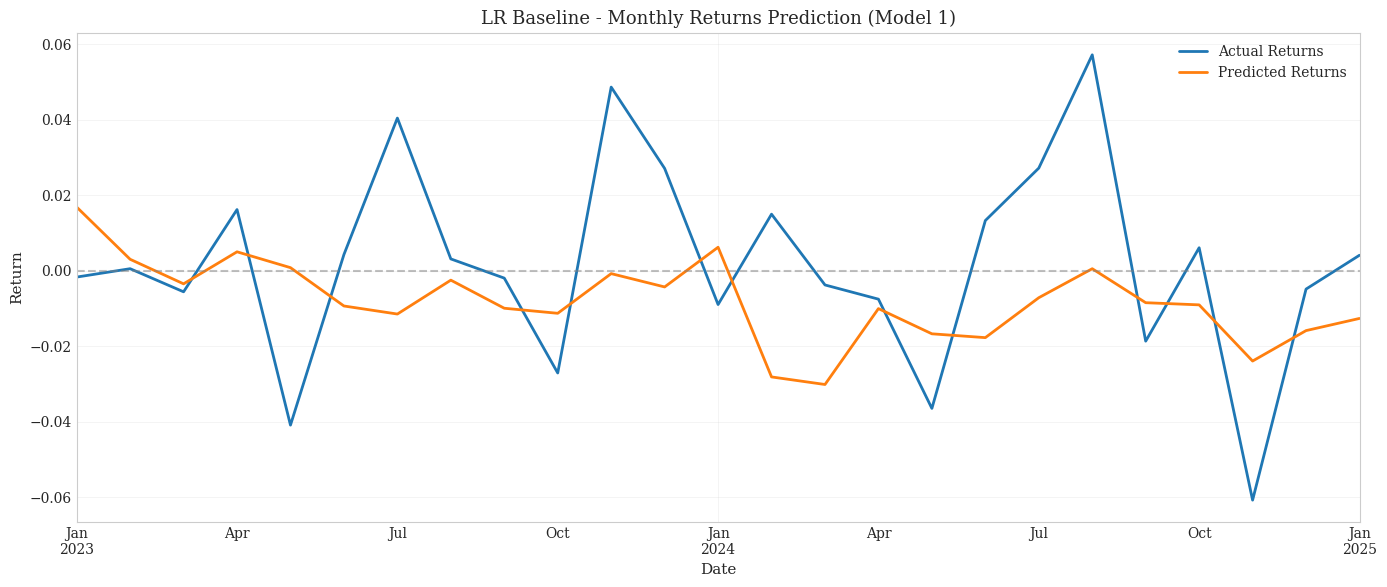

In [19]:
# === Baseline LR Returns ===
lr_ret_model = LinearRegressionModel(
    lags=3,
    lags_past_covariates=3,
    output_chunk_length=1,
    random_state=42
)

lr_ret_model.fit(
    series=ihsg_ret_train_scaled,
    past_covariates=covar_ret_train_scaled
)

# === Historical Forecasts ===
ihsg_ret_full_scaled = ihsg_ret_train_scaled.append(ihsg_ret_test_scaled)

hist_fc_ret_scaled = lr_ret_model.historical_forecasts(
    series=ihsg_ret_full_scaled,
    past_covariates=covar_ret_full_scaled,
    start=len(ihsg_ret_train_scaled),
    forecast_horizon=1,
    stride=1,
    retrain=False,
    verbose=False
)

# === Inverse Transform ===
hist_fc_ret = scaler_RET.inverse_transform(hist_fc_ret_scaled)
ihsg_ret_test_actual = scaler_RET.inverse_transform(ihsg_ret_test_scaled)

# === Metrics ===
print("=== LR Baseline - Returns (Model 1) ===")
print(f"MAPE:  {mape(ihsg_ret_test_actual, hist_fc_ret):.4f}")
print(f"RMSE:  {rmse(ihsg_ret_test_actual, hist_fc_ret):.4f}")
print(f"MAE:   {mae(ihsg_ret_test_actual, hist_fc_ret):.4f}")
print(f"R²:    {r2_score(ihsg_ret_test_actual, hist_fc_ret):.4f}")

# === Directional Accuracy ===
actual_values = ihsg_ret_test_actual.values().flatten()
pred_values = hist_fc_ret.values().flatten()
direction_correct = ((actual_values > 0) == (pred_values > 0)).sum()
directional_accuracy = direction_correct / len(actual_values) * 100
print(f"Directional Accuracy: {directional_accuracy:.2f}%")

# === Plot ===
plt.figure(figsize=(14, 6))
ihsg_ret_test_actual.plot(label="Actual Returns")
hist_fc_ret.plot(label="Predicted Returns")
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.title("LR Baseline - Monthly Returns Prediction (Model 1)")
plt.ylabel("Return")
plt.legend()
plt.tight_layout()
plt.show()

=== RF Baseline - Returns (Model 1) ===
RMSE:  0.0323
MAE:   0.0262
R²:    -0.5035
Directional Accuracy: 48.00%


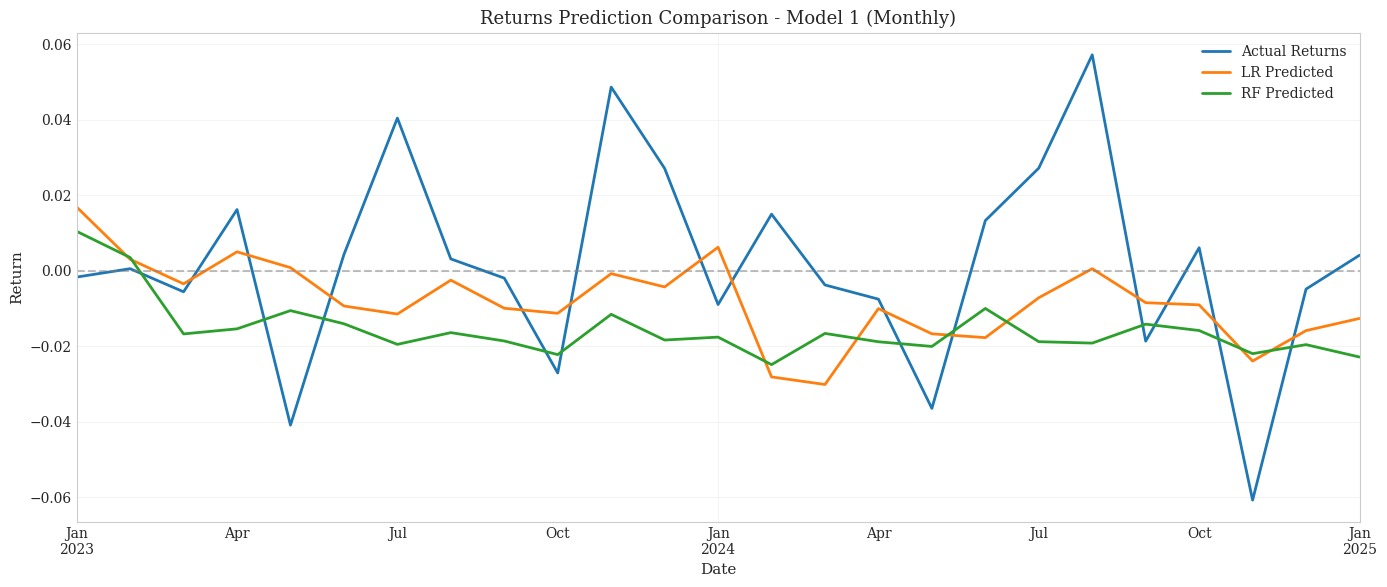

In [20]:
# === Baseline RF Returns ===
rf_ret_model = RandomForestModel(
    lags=3,
    lags_past_covariates=3,
    output_chunk_length=1,
    n_estimators=100,
    max_depth=None,
    random_state=42
)

rf_ret_model.fit(
    series=ihsg_ret_train_scaled,
    past_covariates=covar_ret_train_scaled
)

hist_fc_rf_ret_scaled = rf_ret_model.historical_forecasts(
    series=ihsg_ret_full_scaled,
    past_covariates=covar_ret_full_scaled,
    start=len(ihsg_ret_train_scaled),
    forecast_horizon=1,
    stride=1,
    retrain=False,
    verbose=False
)

hist_fc_rf_ret = scaler_RET.inverse_transform(hist_fc_rf_ret_scaled)

print("=== RF Baseline - Returns (Model 1) ===")
print(f"RMSE:  {rmse(ihsg_ret_test_actual, hist_fc_rf_ret):.4f}")
print(f"MAE:   {mae(ihsg_ret_test_actual, hist_fc_rf_ret):.4f}")
print(f"R²:    {r2_score(ihsg_ret_test_actual, hist_fc_rf_ret):.4f}")

actual_values_rf = ihsg_ret_test_actual.values().flatten()
pred_values_rf = hist_fc_rf_ret.values().flatten()
direction_correct_rf = ((actual_values_rf > 0) == (pred_values_rf > 0)).sum()
directional_accuracy_rf = direction_correct_rf / len(actual_values_rf) * 100
print(f"Directional Accuracy: {directional_accuracy_rf:.2f}%")

# === Plot perbandingan ===
plt.figure(figsize=(14, 6))
ihsg_ret_test_actual.plot(label="Actual Returns")
hist_fc_ret.plot(label="LR Predicted")
hist_fc_rf_ret.plot(label="RF Predicted")
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.title("Returns Prediction Comparison - Model 1 (Monthly)")
plt.ylabel("Return")
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import numpy as np

# === Buat target classification dari returns ===
# 1 = naik (return > 0), 0 = turun (return <= 0)
returns_df = ihsg_returns_df.copy()
returns_df["Direction"] = (returns_df["IHSG_Return"] > 0).astype(int)

print("Class distribution:")
print(returns_df["Direction"].value_counts())
print(f"Ratio naik: {returns_df['Direction'].mean():.2%}")

# === Buat features dari lags (manual, karena classification di luar Darts) ===
# Covariates original (unscaled)
covar_df = covar_train.append(covar_test).to_dataframe()
covar_df = covar_df.iloc[1:]  # trim 1 baris agar align dengan returns

# Gabung returns + covariates
merged = pd.concat([returns_df, covar_df], axis=1)

# Buat lag features
n_lags = 3
for col in merged.columns:
    if col != "Direction":
        for lag in range(1, n_lags + 1):
            merged[f"{col}_lag{lag}"] = merged[col].shift(lag)

# Drop rows dengan NaN (dari lagging) dan kolom original (keep lags only)
original_cols = [c for c in merged.columns if "lag" not in c and c != "Direction"]
merged = merged.drop(columns=original_cols).dropna()

print(f"\nFeatures: {merged.shape[1] - 1}")
print(f"Samples: {len(merged)}")
print(f"Feature names: {[c for c in merged.columns if c != 'Direction']}")

# === Train/Test split ===
split_idx = len(merged) - 25  # 25 bulan test (sama dengan sebelumnya)

X_train = merged.iloc[:split_idx].drop(columns="Direction")
y_train = merged.iloc[:split_idx]["Direction"]
X_test = merged.iloc[split_idx:].drop(columns="Direction")
y_test = merged.iloc[split_idx:]["Direction"]

print(f"\nTrain: {len(X_train)} samples")
print(f"Test: {len(X_test)} samples")
print(f"Train class dist: {y_train.value_counts().to_dict()}")
print(f"Test class dist: {y_test.value_counts().to_dict()}")

# === Logistic Regression (baseline) ===
lr_clf = LogisticRegression(random_state=42, max_iter=1000)
lr_clf.fit(X_train, y_train)
lr_pred = lr_clf.predict(X_test)

print("\n=== Logistic Regression (Baseline) ===")
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print(f"Precision: {precision_score(y_test, lr_pred):.4f}")
print(f"Recall: {recall_score(y_test, lr_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, lr_pred):.4f}")

# === Random Forest Classifier ===
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)
rf_clf.fit(X_train, y_train)
rf_pred = rf_clf.predict(X_test)

print("\n=== Random Forest Classifier ===")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(f"Precision: {precision_score(y_test, rf_pred):.4f}")
print(f"Recall: {recall_score(y_test, rf_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, rf_pred):.4f}")

# === Confusion Matrix ===
print("\n=== Confusion Matrix (RF) ===")
print(confusion_matrix(y_test, rf_pred))
print("\n=== Classification Report (RF) ===")
print(classification_report(y_test, rf_pred, target_names=["Turun", "Naik"]))

Class distribution:
Direction
1    70
0    50
Name: count, dtype: int64
Ratio naik: 58.33%

Features: 12
Samples: 117
Feature names: ['IHSG_Return_lag1', 'IHSG_Return_lag2', 'IHSG_Return_lag3', 'M2_YoY_lag1', 'M2_YoY_lag2', 'M2_YoY_lag3', 'USDIDR_lag1', 'USDIDR_lag2', 'USDIDR_lag3', 'NPL_Ratio_lag1', 'NPL_Ratio_lag2', 'NPL_Ratio_lag3']

Train: 92 samples
Test: 25 samples
Train class dist: {1: 55, 0: 37}
Test class dist: {1: 13, 0: 12}

=== Logistic Regression (Baseline) ===
Accuracy: 0.5600
Precision: 0.5833
Recall: 0.5385
F1-Score: 0.5600

=== Random Forest Classifier ===
Accuracy: 0.5200
Precision: 0.5217
Recall: 0.9231
F1-Score: 0.6667

=== Confusion Matrix (RF) ===
[[ 1 11]
 [ 1 12]]

=== Classification Report (RF) ===
              precision    recall  f1-score   support

       Turun       0.50      0.08      0.14        12
        Naik       0.52      0.92      0.67        13

    accuracy                           0.52        25
   macro avg       0.51      0.50      0.40      

/venv/main/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [22]:
from darts.models import SKLearnClassifierModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# === 1. Prepare target classification ===
# Buat IHSG Direction dari returns yang sudah ada
ihsg_direction_df = ihsg_returns_df.copy()
ihsg_direction_df["IHSG_Direction"] = (ihsg_direction_df["IHSG_Return"] > 0).astype(float)
ihsg_direction_df = ihsg_direction_df[["IHSG_Direction"]]

print("Class distribution:")
print(f"  Naik  (1): {int(ihsg_direction_df['IHSG_Direction'].sum())} bulan ({ihsg_direction_df['IHSG_Direction'].mean()*100:.1f}%)")
print(f"  Turun (0): {int((1-ihsg_direction_df['IHSG_Direction']).sum())} bulan ({(1-ihsg_direction_df['IHSG_Direction'].mean())*100:.1f}%)")

# === 2. Buat TimeSeries ===
target_cls = TimeSeries.from_dataframe(ihsg_direction_df)

# Train/Test split (sama dengan sebelumnya)
split_point = len(ihsg_ret_train)  # 95
target_cls_train = target_cls[:split_point]
target_cls_test = target_cls[split_point:]

# Covariates: pakai yang sudah ada (covar_ret_train_scaled, covar_ret_full_scaled)
print(f"\nTrain: {len(target_cls_train)} months ({target_cls_train.start_time()} to {target_cls_train.end_time()})")
print(f"Test: {len(target_cls_test)} months ({target_cls_test.start_time()} to {target_cls_test.end_time()})")
print(f"Train dist: Naik={int(target_cls_train.values().sum())}, Turun={len(target_cls_train)-int(target_cls_train.values().sum())}")
print(f"Test dist: Naik={int(target_cls_test.values().sum())}, Turun={len(target_cls_test)-int(target_cls_test.values().sum())}")

Class distribution:
  Naik  (1): 70 bulan (58.3%)
  Turun (0): 50 bulan (41.7%)

Train: 95 months (2015-02-28 00:00:00 to 2022-12-31 00:00:00)
Test: 25 months (2023-01-31 00:00:00 to 2025-01-31 00:00:00)
Train dist: Naik=57, Turun=38
Test dist: Naik=13, Turun=12


In [23]:
# === 3. Baseline RF Classifier ===
rf_clf_model = SKLearnClassifierModel(
    model=RandomForestClassifier(n_estimators=100, random_state=42),
    lags=3,
    lags_past_covariates=3,
    output_chunk_length=1
)

rf_clf_model.fit(
    series=target_cls_train,
    past_covariates=covar_ret_full_scaled
)

# === Historical Forecasts ===
target_cls_full = target_cls_train.append(target_cls_test)

hf_cls = rf_clf_model.historical_forecasts(
    series=target_cls_full,
    past_covariates=covar_ret_full_scaled,
    start=len(target_cls_train),
    forecast_horizon=1,
    stride=1,
    retrain=False,
    last_points_only=True,
    show_warnings=False
)

# === Evaluate ===
y_true = target_cls_test.values().flatten()
y_pred = hf_cls.values().flatten()

print("=== RF Classifier Baseline (Model 1) ===")
print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))
print(f"\n{classification_report(y_true, y_pred, target_names=['Turun', 'Naik'])}")

This model will treat target `series` lagged values as numeric input features (and not categorical).


=== RF Classifier Baseline (Model 1) ===
Accuracy:  0.4800
Precision: 0.5000
Recall:    0.9231
F1-Score:  0.6486

Confusion Matrix:
[[ 0 12]
 [ 1 12]]

              precision    recall  f1-score   support

       Turun       0.00      0.00      0.00        12
        Naik       0.50      0.92      0.65        13

    accuracy                           0.48        25
   macro avg       0.25      0.46      0.32        25
weighted avg       0.26      0.48      0.34        25



In [26]:
import optuna

# === 4. Optuna Hyperparameter Tuning ===
def objective_cls(trial):
    lags = trial.suggest_categorical("lags", [1, 3, 6, 12])
    lags_past_covariates = trial.suggest_categorical("lags_past_covariates", [1, 3, 6, 12])
    
    n_estimators = trial.suggest_categorical("n_estimators", [50, 100, 200])
    max_depth = trial.suggest_categorical("max_depth", [3, 5, 7, None])
    max_features = trial.suggest_categorical("max_features", [None, "sqrt", "log2"])
    bootstrap = trial.suggest_categorical("bootstrap", [True, False])
    min_samples_split = trial.suggest_categorical("min_samples_split", [2, 5, 10])
    min_samples_leaf = trial.suggest_categorical("min_samples_leaf", [1, 2, 4])
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])

    model = SKLearnClassifierModel(
        model=RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            max_features=max_features,
            bootstrap=bootstrap,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            criterion=criterion,
            random_state=42,
            n_jobs=-1
        ),
        lags=lags,
        lags_past_covariates=lags_past_covariates,
        output_chunk_length=1
    )

    model.fit(
        series=target_cls_train,
        past_covariates=covar_ret_full_scaled
    )

    hf = model.historical_forecasts(
        series=target_cls_full,
        past_covariates=covar_ret_full_scaled,
        start=len(target_cls_train),
        forecast_horizon=1,
        stride=1,
        retrain=False,
        last_points_only=True,
        show_warnings=False
    )

    y_true = target_cls_test.values().flatten()
    y_pred = hf.values().flatten()
    
    score = f1_score(y_true, y_pred, average='macro')
    return score

def print_callback(study, trial):
    print(f"Trial {trial.number}: F1={trial.value:.4f}, params={trial.params}")
    print(f"  Best so far: F1={study.best_value:.4f}, params={study.best_trial.params}")
    print()

study_cls = optuna.create_study(direction="maximize")
study_cls.optimize(objective_cls, n_trials=200, callbacks=[print_callback])

print("=" * 60)
print(f"Best F1 (macro): {study_cls.best_value:.4f}")
print(f"Best params: {study_cls.best_trial.params}")

# === Run Optuna (maximize F1) ===
study_cls = optuna.create_study(direction="maximize")
study_cls.optimize(objective_cls, n_trials=200, callbacks=[print_callback])

print("=" * 60)
print(f"Best F1 (macro): {study_cls.best_value:.4f}")
print(f"Best params: {study_cls.best_trial.params}")

[I 2026-02-11 03:57:04,242] A new study created in memory with name: no-name-f9d50caa-4666-425d-a2fa-f2e688a4c4ba
This model will treat target `series` lagged values as numeric input features (and not categorical).
[I 2026-02-11 03:57:04,401] Trial 0 finished with value: 0.3055555555555556 and parameters: {'lags': 12, 'lags_past_covariates': 12, 'n_estimators': 50, 'max_depth': 5, 'max_features': 'log2', 'bootstrap': False, 'min_samples_split': 5, 'min_samples_leaf': 1, 'criterion': 'entropy'}. Best is trial 0 with value: 0.3055555555555556.
This model will treat target `series` lagged values as numeric input features (and not categorical).


Trial 0: F1=0.3056, params={'lags': 12, 'lags_past_covariates': 12, 'n_estimators': 50, 'max_depth': 5, 'max_features': 'log2', 'bootstrap': False, 'min_samples_split': 5, 'min_samples_leaf': 1, 'criterion': 'entropy'}
  Best so far: F1=0.3056, params={'lags': 12, 'lags_past_covariates': 12, 'n_estimators': 50, 'max_depth': 5, 'max_features': 'log2', 'bootstrap': False, 'min_samples_split': 5, 'min_samples_leaf': 1, 'criterion': 'entropy'}



[I 2026-02-11 03:57:04,709] Trial 1 finished with value: 0.41666666666666663 and parameters: {'lags': 1, 'lags_past_covariates': 12, 'n_estimators': 100, 'max_depth': 5, 'max_features': 'sqrt', 'bootstrap': True, 'min_samples_split': 10, 'min_samples_leaf': 4, 'criterion': 'entropy'}. Best is trial 1 with value: 0.41666666666666663.
This model will treat target `series` lagged values as numeric input features (and not categorical).
[I 2026-02-11 03:57:04,880] Trial 2 finished with value: 0.34210526315789475 and parameters: {'lags': 3, 'lags_past_covariates': 3, 'n_estimators': 50, 'max_depth': None, 'max_features': 'sqrt', 'bootstrap': True, 'min_samples_split': 2, 'min_samples_leaf': 1, 'criterion': 'entropy'}. Best is trial 1 with value: 0.41666666666666663.
This model will treat target `series` lagged values as numeric input features (and not categorical).


Trial 1: F1=0.4167, params={'lags': 1, 'lags_past_covariates': 12, 'n_estimators': 100, 'max_depth': 5, 'max_features': 'sqrt', 'bootstrap': True, 'min_samples_split': 10, 'min_samples_leaf': 4, 'criterion': 'entropy'}
  Best so far: F1=0.4167, params={'lags': 1, 'lags_past_covariates': 12, 'n_estimators': 100, 'max_depth': 5, 'max_features': 'sqrt', 'bootstrap': True, 'min_samples_split': 10, 'min_samples_leaf': 4, 'criterion': 'entropy'}

Trial 2: F1=0.3421, params={'lags': 3, 'lags_past_covariates': 3, 'n_estimators': 50, 'max_depth': None, 'max_features': 'sqrt', 'bootstrap': True, 'min_samples_split': 2, 'min_samples_leaf': 1, 'criterion': 'entropy'}
  Best so far: F1=0.4167, params={'lags': 1, 'lags_past_covariates': 12, 'n_estimators': 100, 'max_depth': 5, 'max_features': 'sqrt', 'bootstrap': True, 'min_samples_split': 10, 'min_samples_leaf': 4, 'criterion': 'entropy'}



[I 2026-02-11 03:57:05,343] Trial 3 finished with value: 0.5192307692307692 and parameters: {'lags': 6, 'lags_past_covariates': 1, 'n_estimators': 200, 'max_depth': None, 'max_features': None, 'bootstrap': False, 'min_samples_split': 10, 'min_samples_leaf': 1, 'criterion': 'gini'}. Best is trial 3 with value: 0.5192307692307692.
This model will treat target `series` lagged values as numeric input features (and not categorical).


...

Trial 197: F1=0.6795, params={'lags': 6, 'lags_past_covariates': 3, 'n_estimators': 100, 'max_depth': None, 'max_features': 'log2', 'bootstrap': True, 'min_samples_split': 10, 'min_samples_leaf': 2, 'criterion': 'entropy'}
  Best so far: F1=0.6795, params={'lags': 6, 'lags_past_covariates': 3, 'n_estimators': 100, 'max_depth': None, 'max_features': 'log2', 'bootstrap': True, 'min_samples_split': 10, 'min_samples_leaf': 2, 'criterion': 'entropy'}



[I 2026-02-11 03:59:07,577] Trial 198 finished with value: 0.5098039215686274 and parameters: {'lags': 6, 'lags_past_covariates': 3, 'n_estimators': 200, 'max_depth': None, 'max_features': 'log2', 'bootstrap': True, 'min_samples_split': 5, 'min_samples_leaf': 2, 'criterion': 'entropy'}. Best is trial 18 with value: 0.6794871794871795.
This model will treat target `series` lagged values as numeric input features (and not categorical).


Trial 198: F1=0.5098, params={'lags': 6, 'lags_past_covariates': 3, 'n_estimators': 200, 'max_depth': None, 'max_features': 'log2', 'bootstrap': True, 'min_samples_split': 5, 'min_samples_leaf': 2, 'criterion': 'entropy'}
  Best so far: F1=0.6795, params={'lags': 6, 'lags_past_covariates': 3, 'n_estimators': 100, 'max_depth': None, 'max_features': 'log2', 'bootstrap': True, 'min_samples_split': 10, 'min_samples_leaf': 2, 'criterion': 'entropy'}



[I 2026-02-11 03:59:07,937] Trial 199 finished with value: 0.6376811594202898 and parameters: {'lags': 6, 'lags_past_covariates': 3, 'n_estimators': 100, 'max_depth': 5, 'max_features': 'log2', 'bootstrap': True, 'min_samples_split': 10, 'min_samples_leaf': 2, 'criterion': 'gini'}. Best is trial 18 with value: 0.6794871794871795.


Trial 199: F1=0.6377, params={'lags': 6, 'lags_past_covariates': 3, 'n_estimators': 100, 'max_depth': 5, 'max_features': 'log2', 'bootstrap': True, 'min_samples_split': 10, 'min_samples_leaf': 2, 'criterion': 'gini'}
  Best so far: F1=0.6795, params={'lags': 6, 'lags_past_covariates': 3, 'n_estimators': 100, 'max_depth': None, 'max_features': 'log2', 'bootstrap': True, 'min_samples_split': 10, 'min_samples_leaf': 2, 'criterion': 'entropy'}

Best F1 (macro): 0.6795
Best params: {'lags': 6, 'lags_past_covariates': 3, 'n_estimators': 100, 'max_depth': None, 'max_features': 'log2', 'bootstrap': True, 'min_samples_split': 10, 'min_samples_leaf': 2, 'criterion': 'entropy'}


This model will treat target `series` lagged values as numeric input features (and not categorical).


=== RF Classifier Best (Model 1) ===
Accuracy:  0.6800
Precision: 0.6923
Recall:    0.6923
F1-Score:  0.6923
F1 Macro:  0.6795

Confusion Matrix:
[[8 4]
 [4 9]]

              precision    recall  f1-score   support

       Turun       0.67      0.67      0.67        12
        Naik       0.69      0.69      0.69        13

    accuracy                           0.68        25
   macro avg       0.68      0.68      0.68        25
weighted avg       0.68      0.68      0.68        25



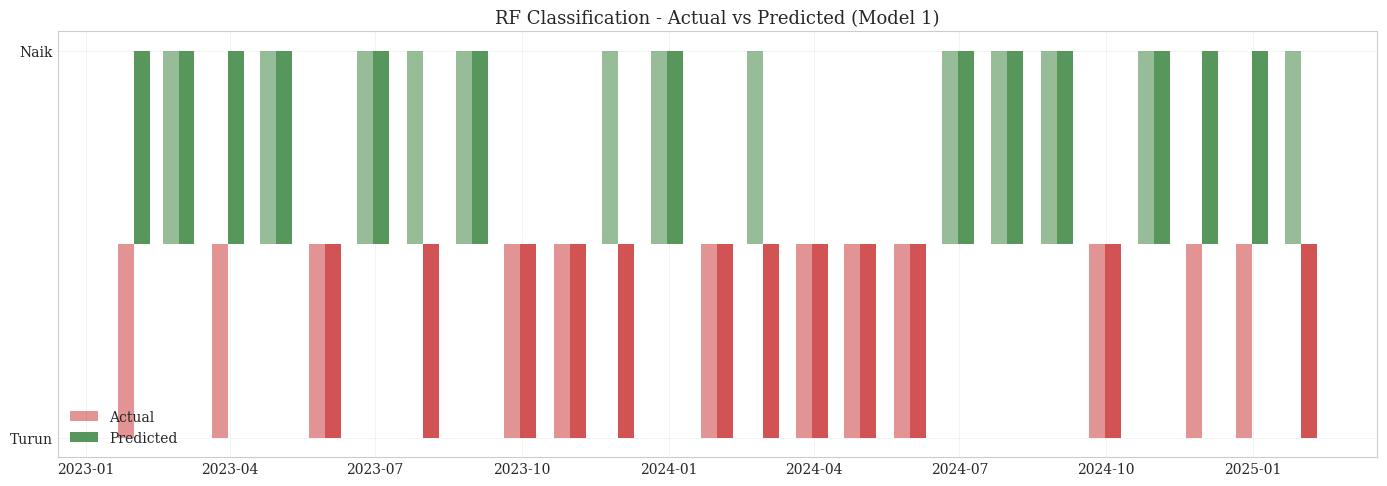

In [28]:
# === Best RF Classifier ===
best_rf_cls = SKLearnClassifierModel(
    model=RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        max_features="log2",
        bootstrap=True,
        min_samples_split=10,
        min_samples_leaf=2,
        criterion="entropy",
        random_state=42,
        n_jobs=-1
    ),
    lags=6,
    lags_past_covariates=3,
    output_chunk_length=1
)

best_rf_cls.fit(
    series=target_cls_train,
    past_covariates=covar_ret_full_scaled
)

hf_cls_best = best_rf_cls.historical_forecasts(
    series=target_cls_full,
    past_covariates=covar_ret_full_scaled,
    start=len(target_cls_train),
    forecast_horizon=1,
    stride=1,
    retrain=False,
    last_points_only=True,
    show_warnings=False
)

# === Evaluate ===
y_true = target_cls_test.values().flatten()
y_pred = hf_cls_best.values().flatten()

print("=== RF Classifier Best (Model 1) ===")
print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")
print(f"F1 Macro:  {f1_score(y_true, y_pred, average='macro'):.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))
print(f"\n{classification_report(y_true, y_pred, target_names=['Turun', 'Naik'])}")

# === Plot timeline ===
fig, ax = plt.subplots(figsize=(14, 5))
dates = target_cls_test.time_index

colors_actual = ['#2E7D32' if v == 1 else '#C62828' for v in y_true]
colors_pred = ['#2E7D32' if v == 1 else '#C62828' for v in y_pred]
correct = y_true == y_pred

ax.bar(dates - pd.Timedelta(days=5), y_true * 2 - 1, width=10, color=colors_actual, alpha=0.5, label="Actual")
ax.bar(dates + pd.Timedelta(days=5), y_pred * 2 - 1, width=10, color=colors_pred, alpha=0.8, label="Predicted")

for i, (d, c) in enumerate(zip(dates, correct)):
    ax.annotate("✓" if c else "✗", (d, 1.2), ha='center', fontsize=10,
                color='green' if c else 'red')

ax.set_yticks([-1, 1])
ax.set_yticklabels(["Turun", "Naik"])
ax.set_title("RF Classification - Actual vs Predicted (Model 1)")
ax.legend()
plt.tight_layout()
plt.show()

The model is probabilistic, but num_samples=1 will be used for explainability.
/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


  0%|          | 0/90 [00:00<?, ?it/s]

/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: U

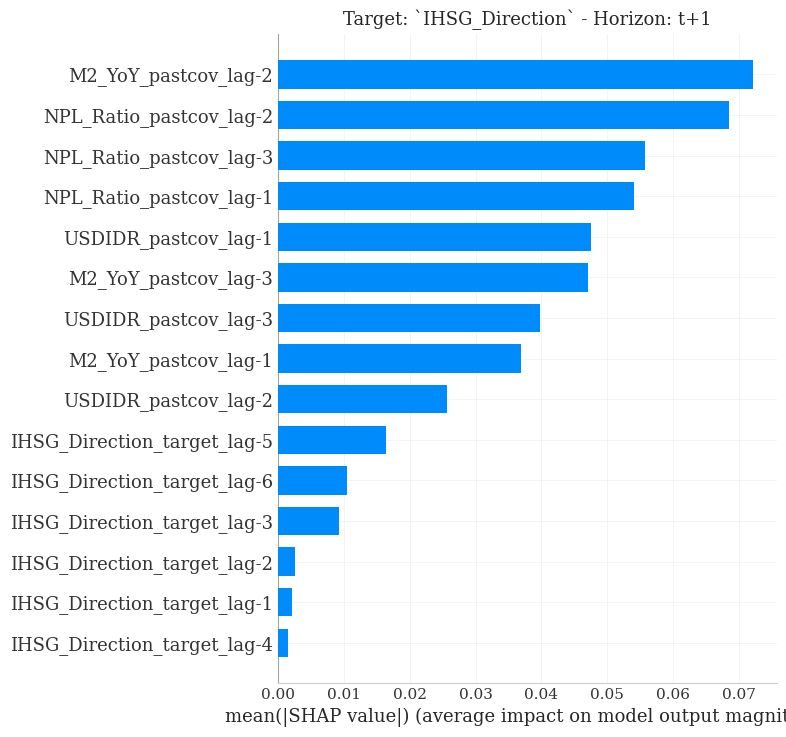

  0%|          | 0/90 [00:00<?, ?it/s]

/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: U

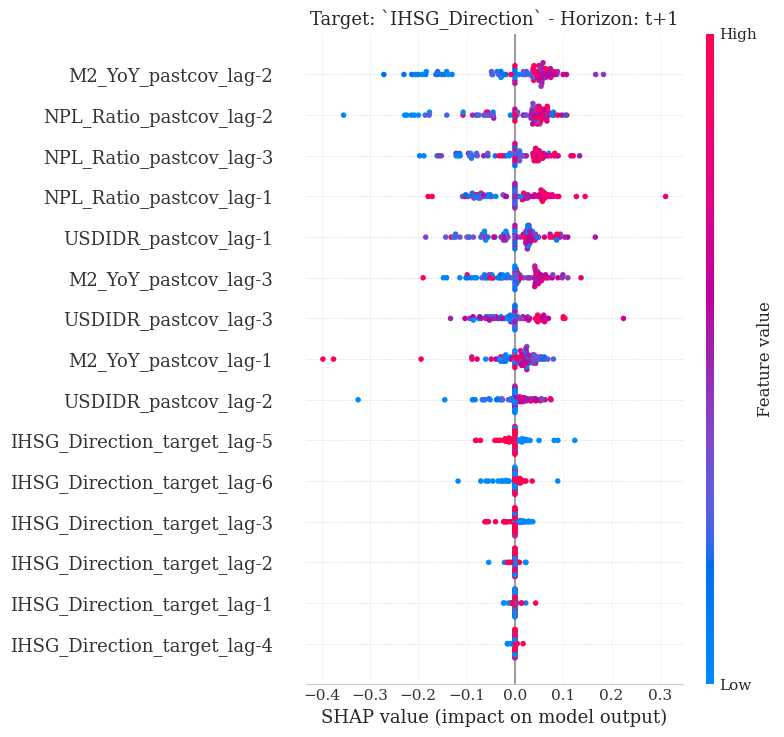

{1: {'IHSG_Direction': .values =
  array([[ 0.        , -0.01959115, -0.0148885 , ..., -0.02949872,
          -0.05591973, -0.06395851],
         [ 0.        ,  0.03141589,  0.        , ..., -0.19406368,
          -0.0628663 , -0.0736166 ],
         [ 0.0006096 ,  0.        ,  0.        , ...,  0.03146558,
           0.06105944,  0.        ],
         ...,
         [-0.02270503,  0.08886018,  0.        , ...,  0.01062033,
           0.        ,  0.        ],
         [-0.04552717, -0.01795773,  0.        , ..., -0.08914895,
          -0.13178575, -0.10201657],
         [ 0.00610599,  0.        ,  0.        , ...,  0.04818714,
           0.01890095,  0.01136143]], shape=(90, 15))
  
  .base_values =
  array([0.68888889, 0.68888889, 0.68888889, 0.68888889, 0.68888889,
         0.68888889, 0.68888889, 0.68888889, 0.68888889, 0.68888889,
         0.68888889, 0.68888889, 0.68888889, 0.68888889, 0.68888889,
         0.68888889, 0.68888889, 0.68888889, 0.68888889, 0.68888889,
         0.68888

In [29]:
# === SHAP Analysis ===
from darts.explainability.shap_explainer import ShapExplainer

shap_cls = ShapExplainer(
    model=best_rf_cls,
    background_series=target_cls_train,
    background_past_covariates=covar_ret_full_scaled
)

shap_cls.summary_plot(horizons=[1], plot_type="bar")
shap_cls.summary_plot(horizons=[1], plot_type="dot")

In [30]:
from sklearn.linear_model import LogisticRegression

# === Baseline Logistic Regression ===
lr_clf_model = SKLearnClassifierModel(
    model=LogisticRegression(random_state=42, max_iter=5000),
    lags=3,
    lags_past_covariates=3,
    output_chunk_length=1
)

lr_clf_model.fit(
    series=target_cls_train,
    past_covariates=covar_ret_full_scaled
)

hf_lr_cls = lr_clf_model.historical_forecasts(
    series=target_cls_full,
    past_covariates=covar_ret_full_scaled,
    start=len(target_cls_train),
    forecast_horizon=1,
    stride=1,
    retrain=False,
    last_points_only=True,
    show_warnings=False
)

y_true = target_cls_test.values().flatten()
y_pred_lr = hf_lr_cls.values().flatten()

print("=== Logistic Regression Baseline (Model 1) ===")
print(f"Accuracy:  {accuracy_score(y_true, y_pred_lr):.4f}")
print(f"F1 Macro:  {f1_score(y_true, y_pred_lr, average='macro'):.4f}")
print(f"\n{classification_report(y_true, y_pred_lr, target_names=['Turun', 'Naik'])}")

# === Optuna Logistic Regression ===
def objective_lr_cls(trial):
    lags = trial.suggest_categorical("lags", [1, 3, 6, 12])
    lags_past_covariates = trial.suggest_categorical("lags_past_covariates", [1, 3, 6, 12])
    C = trial.suggest_float("C", 0.001, 100, log=True)
    penalty = trial.suggest_categorical("penalty", ["l1", "l2"])
    solver = "liblinear"  # supports both l1 and l2

    model = SKLearnClassifierModel(
        model=LogisticRegression(
            C=C,
            penalty=penalty,
            solver=solver,
            random_state=42,
            max_iter=5000
        ),
        lags=lags,
        lags_past_covariates=lags_past_covariates,
        output_chunk_length=1
    )

    model.fit(
        series=target_cls_train,
        past_covariates=covar_ret_full_scaled
    )

    hf = model.historical_forecasts(
        series=target_cls_full,
        past_covariates=covar_ret_full_scaled,
        start=len(target_cls_train),
        forecast_horizon=1,
        stride=1,
        retrain=False,
        last_points_only=True,
        show_warnings=False
    )

    y_true = target_cls_test.values().flatten()
    y_pred = hf.values().flatten()
    
    return f1_score(y_true, y_pred, average='macro')

study_lr_cls = optuna.create_study(direction="maximize")
study_lr_cls.optimize(objective_lr_cls, n_trials=100, callbacks=[print_callback])

print("=" * 60)
print(f"Best F1 (macro): {study_lr_cls.best_value:.4f}")
print(f"Best params: {study_lr_cls.best_trial.params}")

This model will treat target `series` lagged values as numeric input features (and not categorical).
[I 2026-02-11 04:25:17,333] A new study created in memory with name: no-name-482b6a4f-d646-4d85-9df9-1d728c2560bd
This model will treat target `series` lagged values as numeric input features (and not categorical).
[I 2026-02-11 04:25:17,358] Trial 0 finished with value: 0.3055555555555556 and parameters: {'lags': 1, 'lags_past_covariates': 12, 'C': 0.31124933362669593, 'penalty': 'l2'}. Best is trial 0 with value: 0.3055555555555556.
This model will treat target `series` lagged values as numeric input features (and not categorical).
[I 2026-02-11 04:25:17,378] Trial 1 finished with value: 0.3055555555555556 and parameters: {'lags': 1, 'lags_past_covariates': 12, 'C': 0.4211770214215815, 'penalty': 'l1'}. Best is trial 0 with value: 0.3055555555555556.
This model will treat target `series` lagged values as numeric input features (and not categorical).
[I 2026-02-11 04:25:17,396] Trial 2

=== Logistic Regression Baseline (Model 1) ===
Accuracy:  0.4800
F1 Macro:  0.4207

              precision    recall  f1-score   support

       Turun       0.48      0.83      0.61        12
        Naik       0.50      0.15      0.24        13

    accuracy                           0.48        25
   macro avg       0.49      0.49      0.42        25
weighted avg       0.49      0.48      0.41        25

Trial 0: F1=0.3056, params={'lags': 1, 'lags_past_covariates': 12, 'C': 0.31124933362669593, 'penalty': 'l2'}
  Best so far: F1=0.3056, params={'lags': 1, 'lags_past_covariates': 12, 'C': 0.31124933362669593, 'penalty': 'l2'}

Trial 1: F1=0.3056, params={'lags': 1, 'lags_past_covariates': 12, 'C': 0.4211770214215815, 'penalty': 'l1'}
  Best so far: F1=0.3056, params={'lags': 1, 'lags_past_covariates': 12, 'C': 0.31124933362669593, 'penalty': 'l2'}

Trial 2: F1=0.3243, params={'lags': 1, 'lags_past_covariates': 12, 'C': 0.0016545637129075413, 'penalty': 'l1'}
  Best so far: F1=0.3243

[I 2026-02-11 04:25:17,525] Trial 7 finished with value: 0.6376811594202898 and parameters: {'lags': 3, 'lags_past_covariates': 12, 'C': 60.03186413378621, 'penalty': 'l1'}. Best is trial 7 with value: 0.6376811594202898.
This model will treat target `series` lagged values as numeric input features (and not categorical).
[I 2026-02-11 04:25:17,538] Trial 8 finished with value: 0.32432432432432434 and parameters: {'lags': 3, 'lags_past_covariates': 3, 'C': 0.03520921858380117, 'penalty': 'l1'}. Best is trial 7 with value: 0.6376811594202898.
This model will treat target `series` lagged values as numeric input features (and not categorical).
[I 2026-02-11 04:25:17,552] Trial 9 finished with value: 0.5098039215686274 and parameters: {'lags': 12, 'lags_past_covariates': 1, 'C': 60.62809666720193, 'penalty': 'l1'}. Best is trial 7 with value: 0.6376811594202898.
This model will treat target `series` lagged values as numeric input features (and not categorical).
[I 2026-02-11 04:25:17,569] T

Trial 7: F1=0.6377, params={'lags': 3, 'lags_past_covariates': 12, 'C': 60.03186413378621, 'penalty': 'l1'}
  Best so far: F1=0.6377, params={'lags': 3, 'lags_past_covariates': 12, 'C': 60.03186413378621, 'penalty': 'l1'}

Trial 8: F1=0.3243, params={'lags': 3, 'lags_past_covariates': 3, 'C': 0.03520921858380117, 'penalty': 'l1'}
  Best so far: F1=0.6377, params={'lags': 3, 'lags_past_covariates': 12, 'C': 60.03186413378621, 'penalty': 'l1'}

Trial 9: F1=0.5098, params={'lags': 12, 'lags_past_covariates': 1, 'C': 60.62809666720193, 'penalty': 'l1'}
  Best so far: F1=0.6377, params={'lags': 3, 'lags_past_covariates': 12, 'C': 60.03186413378621, 'penalty': 'l1'}

Trial 10: F1=0.4207, params={'lags': 3, 'lags_past_covariates': 3, 'C': 3.810618864294073, 'penalty': 'l2'}
  Best so far: F1=0.6377, params={'lags': 3, 'lags_past_covariates': 12, 'C': 60.03186413378621, 'penalty': 'l1'}

Trial 11: F1=0.4482, params={'lags': 3, 'lags_past_covariates': 12, 'C': 5.3802207066057965, 'penalty': 'l1

[I 2026-02-11 04:25:17,736] Trial 19 finished with value: 0.3055555555555556 and parameters: {'lags': 3, 'lags_past_covariates': 12, 'C': 0.6234303366711491, 'penalty': 'l1'}. Best is trial 7 with value: 0.6376811594202898.
This model will treat target `series` lagged values as numeric input features (and not categorical).
[I 2026-02-11 04:25:17,753] Trial 20 finished with value: 0.32432432432432434 and parameters: {'lags': 1, 'lags_past_covariates': 12, 'C': 0.06388917685634807, 'penalty': 'l1'}. Best is trial 7 with value: 0.6376811594202898.
This model will treat target `series` lagged values as numeric input features (and not categorical).
[I 2026-02-11 04:25:17,778] Trial 21 finished with value: 0.6179966044142615 and parameters: {'lags': 1, 'lags_past_covariates': 12, 'C': 17.794048623852348, 'penalty': 'l1'}. Best is trial 7 with value: 0.6376811594202898.
This model will treat target `series` lagged values as numeric input features (and not categorical).
[I 2026-02-11 04:25:17,

...

Trial 82: F1=0.7126, params={'lags': 1, 'lags_past_covariates': 12, 'C': 36.62382072606831, 'penalty': 'l1'}
  Best so far: F1=0.7126, params={'lags': 1, 'lags_past_covariates': 12, 'C': 29.63289208234379, 'penalty': 'l1'}

Trial 83: F1=0.6667, params={'lags': 1, 'lags_past_covariates': 12, 'C': 25.165138663144155, 'penalty': 'l1'}
  Best so far: F1=0.7126, params={'lags': 1, 'lags_past_covariates': 12, 'C': 29.63289208234379, 'penalty': 'l1'}

Trial 84: F1=0.6180, params={'lags': 1, 'lags_past_covariates': 12, 'C': 16.07946630072137, 'penalty': 'l1'}
  Best so far: F1=0.7126, params={'lags': 1, 'lags_past_covariates': 12, 'C': 29.63289208234379, 'penalty': 'l1'}

Trial 85: F1=0.3243, params={'lags': 1, 'lags_past_covariates': 12, 'C': 0.018952343162877392, 'penalty': 'l1'}
  Best so far: F1=0.7126, params={'lags': 1, 'lags_past_covariates': 12, 'C': 29.63289208234379, 'penalty': 'l1'}

Trial 86: F1=0.4048, params={'lags': 1, 'lags_past_covariates': 1, 'C': 58.936236110538644, 'penalty

This model will treat target `series` lagged values as numeric input features (and not categorical).
[I 2026-02-11 04:25:19,992] Trial 90 finished with value: 0.5571658615136876 and parameters: {'lags': 12, 'lags_past_covariates': 12, 'C': 42.83602911371133, 'penalty': 'l1'}. Best is trial 31 with value: 0.7126436781609196.
This model will treat target `series` lagged values as numeric input features (and not categorical).
[I 2026-02-11 04:25:20,040] Trial 91 finished with value: 0.7126436781609196 and parameters: {'lags': 1, 'lags_past_covariates': 12, 'C': 38.98571101144357, 'penalty': 'l1'}. Best is trial 31 with value: 0.7126436781609196.
This model will treat target `series` lagged values as numeric input features (and not categorical).
[I 2026-02-11 04:25:20,080] Trial 92 finished with value: 0.7126436781609196 and parameters: {'lags': 1, 'lags_past_covariates': 12, 'C': 30.899808901586265, 'penalty': 'l1'}. Best is trial 31 with value: 0.7126436781609196.
This model will treat t

Trial 90: F1=0.5572, params={'lags': 12, 'lags_past_covariates': 12, 'C': 42.83602911371133, 'penalty': 'l1'}
  Best so far: F1=0.7126, params={'lags': 1, 'lags_past_covariates': 12, 'C': 29.63289208234379, 'penalty': 'l1'}

Trial 91: F1=0.7126, params={'lags': 1, 'lags_past_covariates': 12, 'C': 38.98571101144357, 'penalty': 'l1'}
  Best so far: F1=0.7126, params={'lags': 1, 'lags_past_covariates': 12, 'C': 29.63289208234379, 'penalty': 'l1'}

Trial 92: F1=0.7126, params={'lags': 1, 'lags_past_covariates': 12, 'C': 30.899808901586265, 'penalty': 'l1'}
  Best so far: F1=0.7126, params={'lags': 1, 'lags_past_covariates': 12, 'C': 29.63289208234379, 'penalty': 'l1'}

Trial 93: F1=0.6180, params={'lags': 1, 'lags_past_covariates': 12, 'C': 13.502401355058236, 'penalty': 'l1'}
  Best so far: F1=0.7126, params={'lags': 1, 'lags_past_covariates': 12, 'C': 29.63289208234379, 'penalty': 'l1'}

Trial 94: F1=0.6180, params={'lags': 1, 'lags_past_covariates': 12, 'C': 20.106401337452734, 'penalty

[I 2026-02-11 04:25:20,228] Trial 96 finished with value: 0.7126436781609196 and parameters: {'lags': 1, 'lags_past_covariates': 12, 'C': 32.484501314322024, 'penalty': 'l1'}. Best is trial 31 with value: 0.7126436781609196.
This model will treat target `series` lagged values as numeric input features (and not categorical).
[I 2026-02-11 04:25:20,246] Trial 97 finished with value: 0.47916666666666663 and parameters: {'lags': 1, 'lags_past_covariates': 12, 'C': 6.562686342923864, 'penalty': 'l2'}. Best is trial 31 with value: 0.7126436781609196.
This model will treat target `series` lagged values as numeric input features (and not categorical).
[I 2026-02-11 04:25:20,271] Trial 98 finished with value: 0.6179966044142615 and parameters: {'lags': 1, 'lags_past_covariates': 12, 'C': 16.774181474109934, 'penalty': 'l1'}. Best is trial 31 with value: 0.7126436781609196.
This model will treat target `series` lagged values as numeric input features (and not categorical).
[I 2026-02-11 04:25:20

Trial 96: F1=0.7126, params={'lags': 1, 'lags_past_covariates': 12, 'C': 32.484501314322024, 'penalty': 'l1'}
  Best so far: F1=0.7126, params={'lags': 1, 'lags_past_covariates': 12, 'C': 29.63289208234379, 'penalty': 'l1'}

Trial 97: F1=0.4792, params={'lags': 1, 'lags_past_covariates': 12, 'C': 6.562686342923864, 'penalty': 'l2'}
  Best so far: F1=0.7126, params={'lags': 1, 'lags_past_covariates': 12, 'C': 29.63289208234379, 'penalty': 'l1'}

Trial 98: F1=0.6180, params={'lags': 1, 'lags_past_covariates': 12, 'C': 16.774181474109934, 'penalty': 'l1'}
  Best so far: F1=0.7126, params={'lags': 1, 'lags_past_covariates': 12, 'C': 29.63289208234379, 'penalty': 'l1'}

Trial 99: F1=0.6753, params={'lags': 1, 'lags_past_covariates': 12, 'C': 94.04301549181878, 'penalty': 'l1'}
  Best so far: F1=0.7126, params={'lags': 1, 'lags_past_covariates': 12, 'C': 29.63289208234379, 'penalty': 'l1'}

Best F1 (macro): 0.7126
Best params: {'lags': 1, 'lags_past_covariates': 12, 'C': 29.63289208234379, '

This model will treat target `series` lagged values as numeric input features (and not categorical).
The model is probabilistic, but num_samples=1 will be used for explainability.


=== Logistic Regression Best (Model 1) ===
Accuracy:  0.7200
Precision: 0.8750
Recall:    0.5385
F1-Score:  0.6667
F1 Macro:  0.7126

Confusion Matrix:
[[11  1]
 [ 6  7]]

              precision    recall  f1-score   support

       Turun       0.65      0.92      0.76        12
        Naik       0.88      0.54      0.67        13

    accuracy                           0.72        25
   macro avg       0.76      0.73      0.71        25
weighted avg       0.77      0.72      0.71        25



/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


  0%|          | 0/84 [00:00<?, ?it/s]

/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has fe

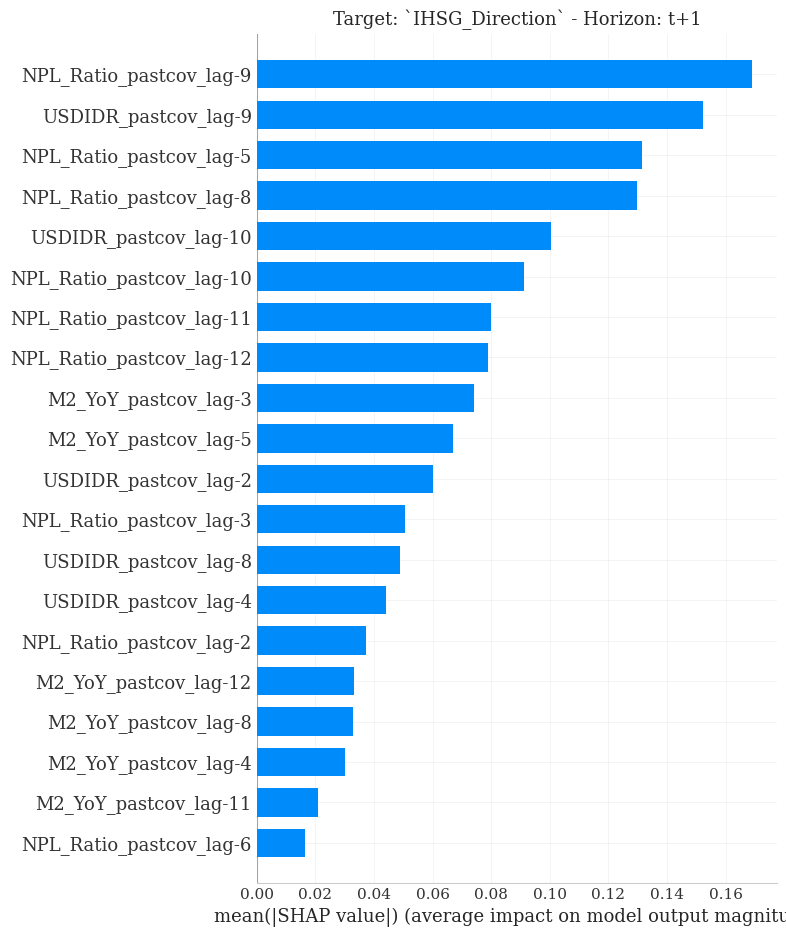

  0%|          | 0/84 [00:00<?, ?it/s]

/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has fe

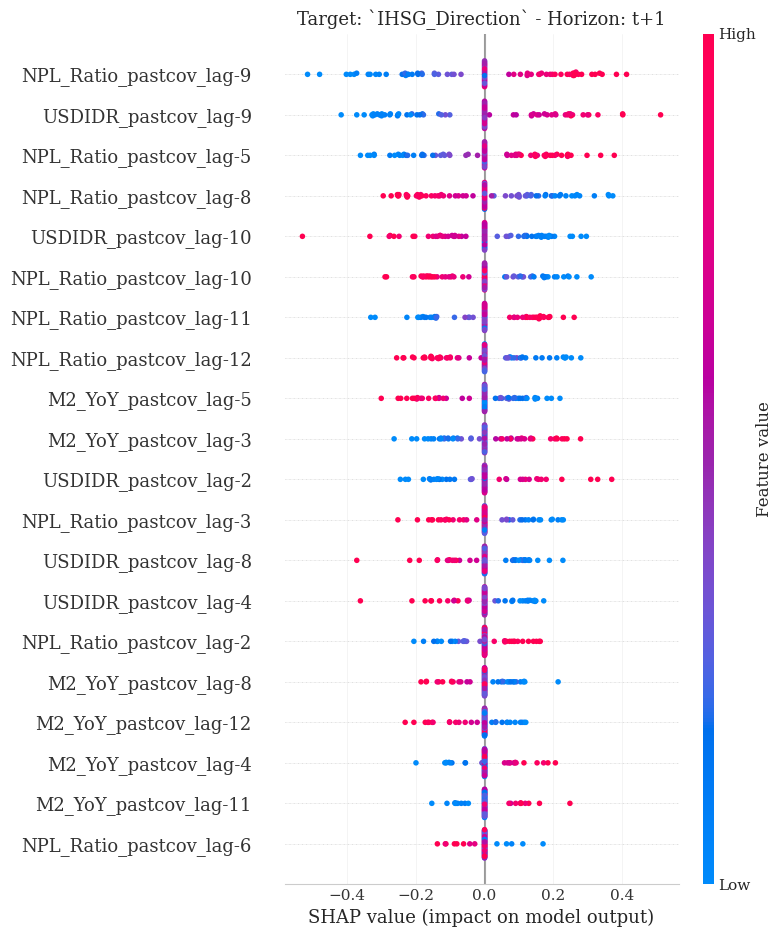

NameError: name 'plot_optimization_history' is not defined

In [31]:
# === Best Logistic Regression Classifier ===
best_lr_cls = SKLearnClassifierModel(
    model=LogisticRegression(
        C=29.633,
        penalty="l1",
        solver="liblinear",
        random_state=42,
        max_iter=5000
    ),
    lags=1,
    lags_past_covariates=12,
    output_chunk_length=1
)

best_lr_cls.fit(
    series=target_cls_train,
    past_covariates=covar_ret_full_scaled
)

hf_lr_cls_best = best_lr_cls.historical_forecasts(
    series=target_cls_full,
    past_covariates=covar_ret_full_scaled,
    start=len(target_cls_train),
    forecast_horizon=1,
    stride=1,
    retrain=False,
    last_points_only=True,
    show_warnings=False
)

y_true = target_cls_test.values().flatten()
y_pred_lr = hf_lr_cls_best.values().flatten()

print("=== Logistic Regression Best (Model 1) ===")
print(f"Accuracy:  {accuracy_score(y_true, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_true, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred_lr):.4f}")
print(f"F1-Score:  {f1_score(y_true, y_pred_lr):.4f}")
print(f"F1 Macro:  {f1_score(y_true, y_pred_lr, average='macro'):.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred_lr))
print(f"\n{classification_report(y_true, y_pred_lr, target_names=['Turun', 'Naik'])}")

# === SHAP ===
shap_lr_cls = ShapExplainer(
    model=best_lr_cls,
    background_series=target_cls_train,
    background_past_covariates=covar_ret_full_scaled
)

shap_lr_cls.summary_plot(horizons=[1], plot_type="bar")
shap_lr_cls.summary_plot(horizons=[1], plot_type="dot")

# === Optuna visualization ===
fig1 = plot_optimization_history(study_lr_cls)
fig1.show()
fig2 = plot_param_importances(study_lr_cls)
fig2.show()

In [32]:
print(best_lr_cls.lagged_feature_names)

['IHSG_Direction_target_lag-1', 'M2_YoY_pastcov_lag-12', 'USDIDR_pastcov_lag-12', 'NPL_Ratio_pastcov_lag-12', 'M2_YoY_pastcov_lag-11', 'USDIDR_pastcov_lag-11', 'NPL_Ratio_pastcov_lag-11', 'M2_YoY_pastcov_lag-10', 'USDIDR_pastcov_lag-10', 'NPL_Ratio_pastcov_lag-10', 'M2_YoY_pastcov_lag-9', 'USDIDR_pastcov_lag-9', 'NPL_Ratio_pastcov_lag-9', 'M2_YoY_pastcov_lag-8', 'USDIDR_pastcov_lag-8', 'NPL_Ratio_pastcov_lag-8', 'M2_YoY_pastcov_lag-7', 'USDIDR_pastcov_lag-7', 'NPL_Ratio_pastcov_lag-7', 'M2_YoY_pastcov_lag-6', 'USDIDR_pastcov_lag-6', 'NPL_Ratio_pastcov_lag-6', 'M2_YoY_pastcov_lag-5', 'USDIDR_pastcov_lag-5', 'NPL_Ratio_pastcov_lag-5', 'M2_YoY_pastcov_lag-4', 'USDIDR_pastcov_lag-4', 'NPL_Ratio_pastcov_lag-4', 'M2_YoY_pastcov_lag-3', 'USDIDR_pastcov_lag-3', 'NPL_Ratio_pastcov_lag-3', 'M2_YoY_pastcov_lag-2', 'USDIDR_pastcov_lag-2', 'NPL_Ratio_pastcov_lag-2', 'M2_YoY_pastcov_lag-1', 'USDIDR_pastcov_lag-1', 'NPL_Ratio_pastcov_lag-1']
